# PRML Assignment 2 - Image Compression


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
def read_image(path):
    img = Image.open(path).convert('L')
    return np.array(img, dtype=float)

In [3]:
def get_evd(img_matrix):
    vals, vecs = np.linalg.eig(img_matrix)
    idx = np.argsort(np.abs(vals))[::-1]
    sorted_vals = vals[idx]
    sorted_vecs = vecs[:, idx]
    v_inv = np.linalg.inv(sorted_vecs)
    return sorted_vals, sorted_vecs, v_inv

def get_svd(img_matrix):
    u, s, vt = np.linalg.svd(img_matrix, full_matrices=False)
    return u, s, vt

In [ ]:
def recon_evd(vals, vecs, v_inv, k):
    if k > 0 and k < len(vals) and np.isclose(vals[k], np.conj(vals[k - 1])):
        k += 1

    D_k = np.diag(vals[:k])
    V_k = vecs[:, :k]
    res = V_k @ D_k @ v_inv[:k, :]
    
    max_imag = np.max(np.abs(res.imag))
    if max_imag > 1e-9:
        print(f"Imaginary Part Found (k={k}): {max_imag}")
        
    return np.real(res)

def recon_svd(u, s, vt, k):
    return u[:, :k] @ np.diag(s[:k]) @ vt[:k, :]

In [5]:
def calculate_error(orig, recon):
    return np.linalg.norm(orig - recon, 'fro')

def display_results(orig, recon, k, method):
    diff = np.abs(orig - recon)
    err = calculate_error(orig, recon)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(orig, cmap='gray')
    ax[0].set_title("Original")
    ax[0].axis('off')
    
    ax[1].imshow(np.clip(recon, 0, 255), cmap='gray')
    ax[1].set_title(f"{method} Reconstruction (k={k})")
    ax[1].axis('off')
    
    ax[2].imshow(diff, cmap='gray')
    ax[2].set_title(f"Error: {err:.2f}")
    ax[2].axis('off')
    
    plt.show()

### 1. Square Image Analysis

Square image shape: (512, 512)

--- EVD Results ---


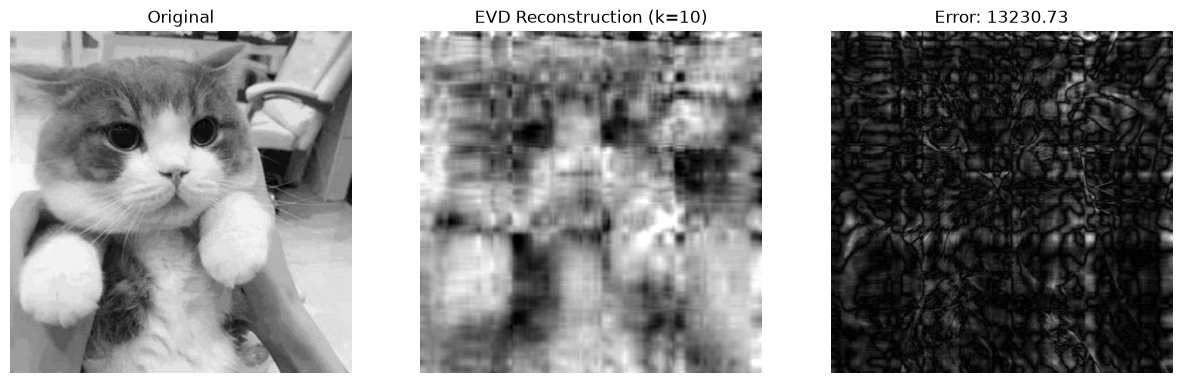

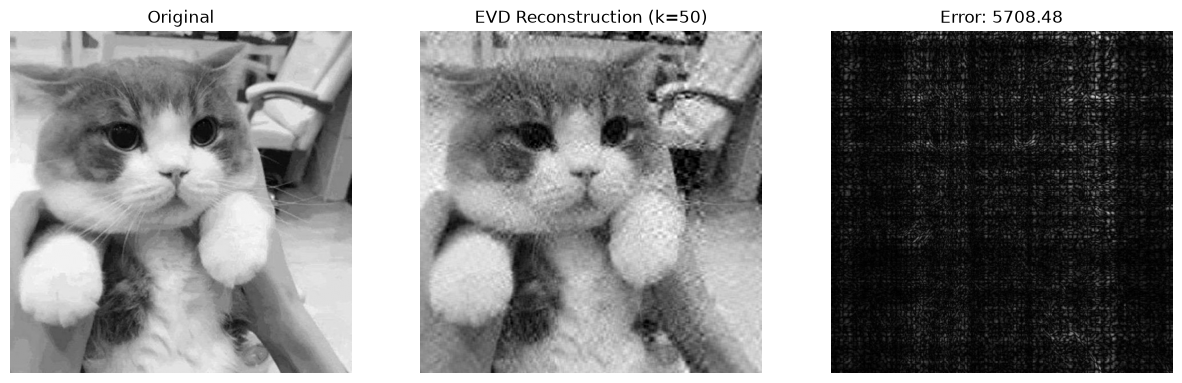

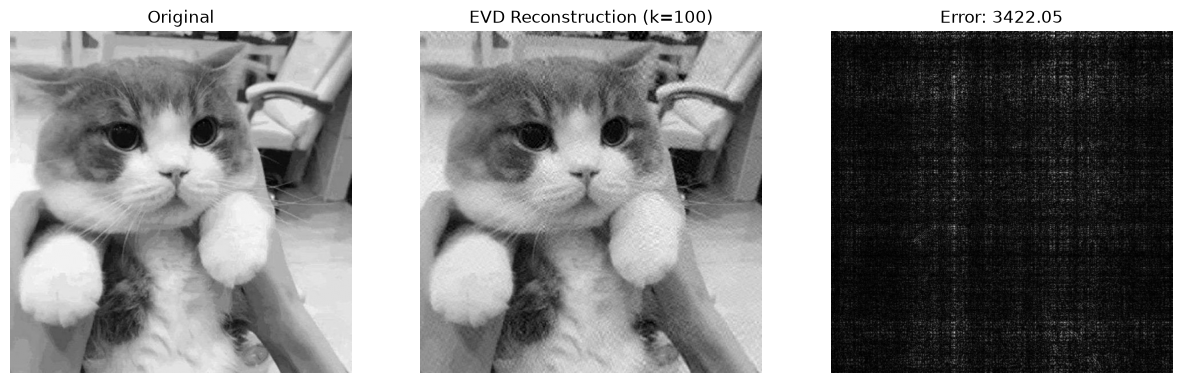


--- SVD Results ---


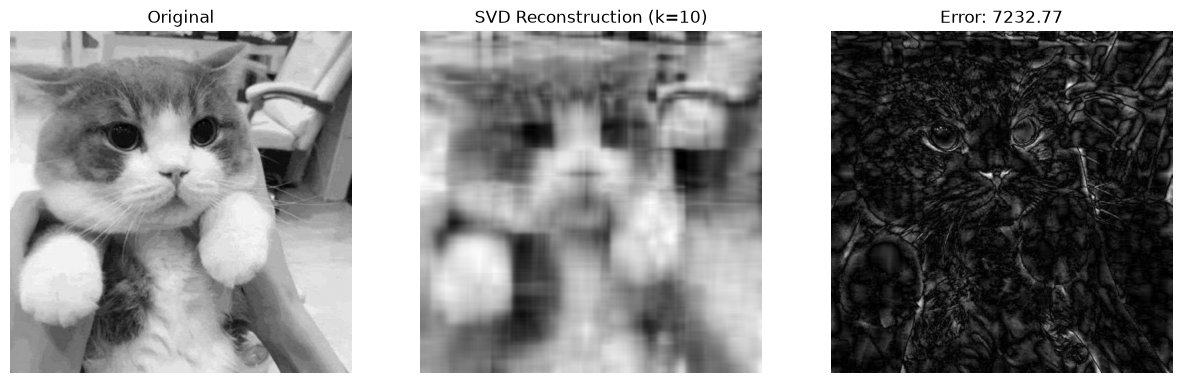

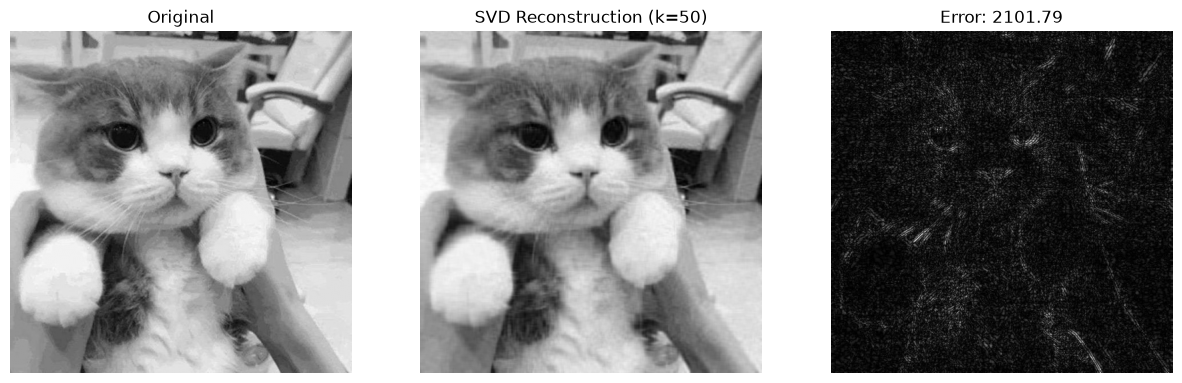

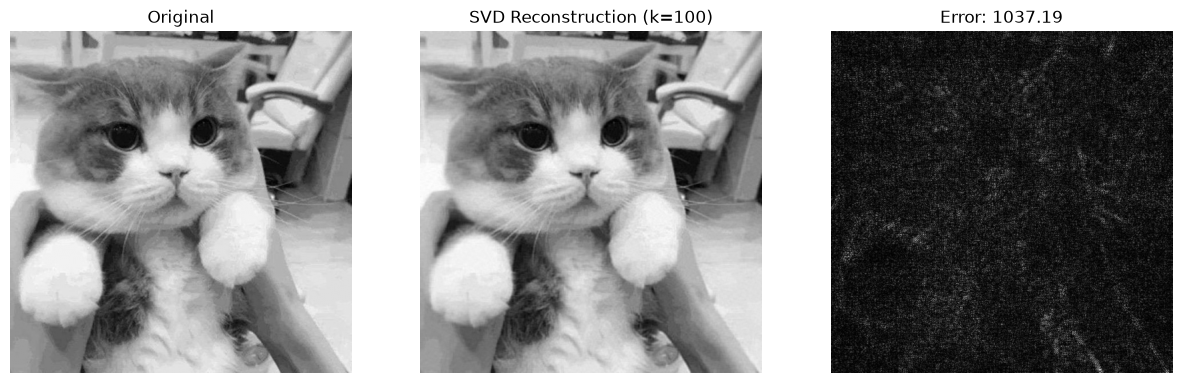

In [6]:
cat_square = read_image("cat_10.png")
print("Square image shape:", cat_square.shape)

if cat_square.shape[0] == cat_square.shape[1]:
    vals, vecs, v_inv = get_evd(cat_square)
    u, s, vt = get_svd(cat_square)
    k_list = [10, 50, 100]
    
    print("\n--- EVD Results ---")
    for k in k_list:
        recon = recon_evd(vals, vecs, v_inv, k)
        display_results(cat_square, recon, k, "EVD")
        
    print("\n--- SVD Results ---")
    for k in k_list:
        recon = recon_svd(u, s, vt, k)
        display_results(cat_square, recon, k, "SVD")

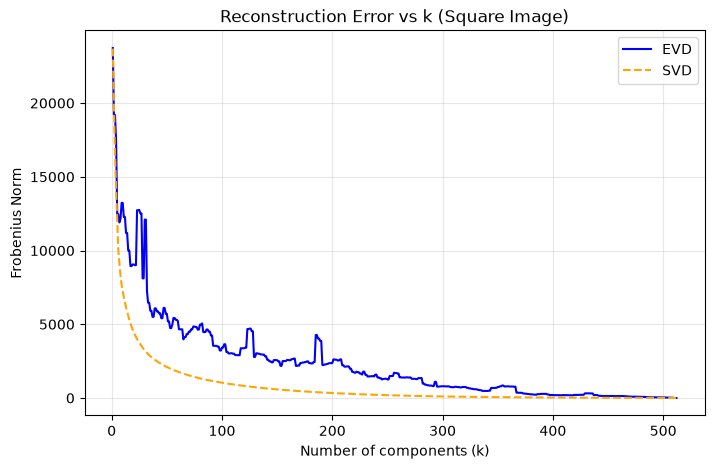

In [7]:
max_k = min(cat_square.shape)
ks = list(range(1, max_k + 1))

err_evd = [calculate_error(cat_square, recon_evd(vals, vecs, v_inv, k)) for k in ks]
err_svd = [calculate_error(cat_square, recon_svd(u, s, vt, k)) for k in ks]

plt.figure(figsize=(8, 5))
plt.plot(ks, err_evd, label="EVD", color='blue')
plt.plot(ks, err_svd, label="SVD", color='orange', linestyle='--')
plt.xlabel("Number of components (k)")
plt.ylabel("Frobenius Norm")
plt.title("Reconstruction Error vs k (Square Image)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Rectangular Image Analysis

Rectangular image shape: (960, 1280)


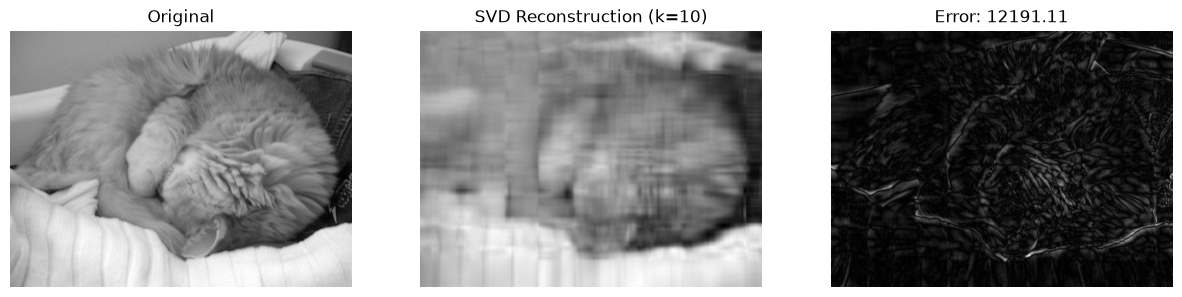

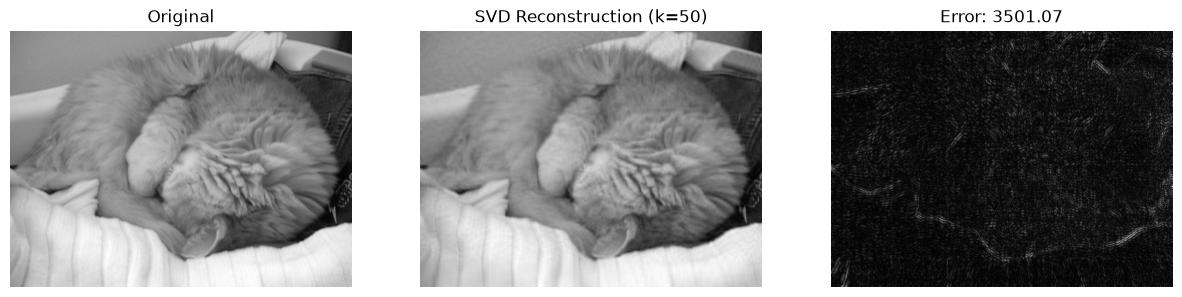

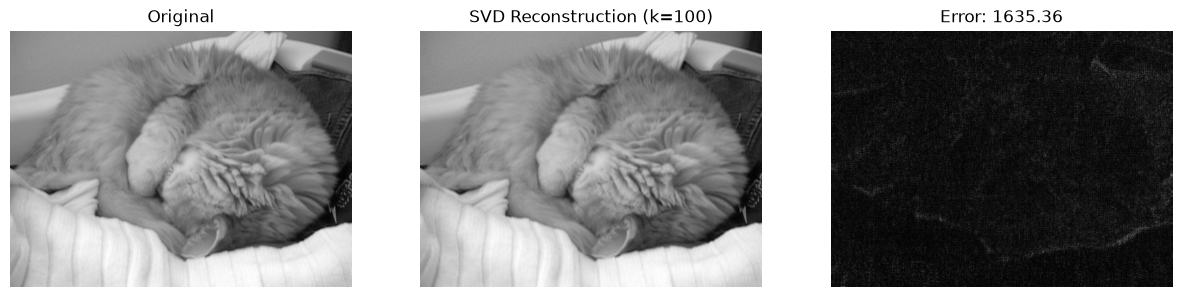

In [8]:
cat_rect = read_image("cat_10 (1).png")
print("Rectangular image shape:", cat_rect.shape)

u_rect, s_rect, vt_rect = get_svd(cat_rect)
max_k_rect = min(cat_rect.shape)

for k in k_list:
    if k <= max_k_rect:
        recon = recon_svd(u_rect, s_rect, vt_rect, k)
        display_results(cat_rect, recon, k, "SVD")

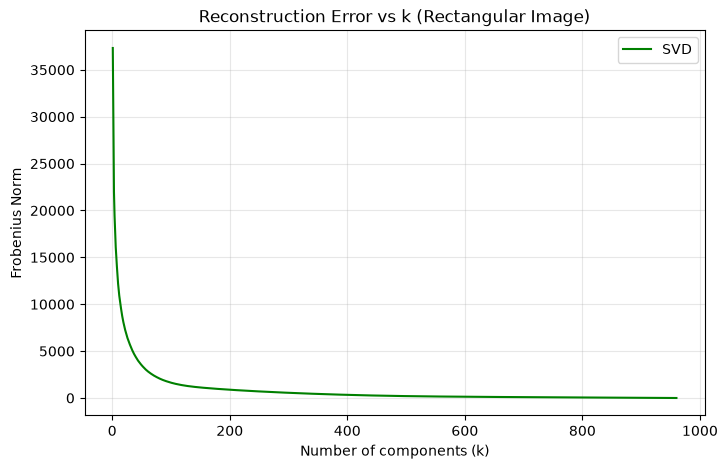

In [9]:
ks_rect = list(range(1, max_k_rect + 1))
err_svd_rect = [calculate_error(cat_rect, recon_svd(u_rect, s_rect, vt_rect, k)) for k in ks_rect]

plt.figure(figsize=(8, 5))
plt.plot(ks_rect, err_svd_rect, label="SVD", color='green')
plt.xlabel("Number of components (k)")
plt.ylabel("Frobenius Norm")
plt.title("Reconstruction Error vs k (Rectangular Image)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()